In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, roc_curve, auc
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve
from sklearn.inspection import PartialDependenceDisplay

In [2]:
def split_train_test(df, features_col, target_col, stratify = None):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42, stratify = stratify)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train, model, kwargs = {}):
    model = model(**kwargs)
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test, proba = False):
    if proba:
        return model.predict_proba(X_test)[:, 1]
    else:
        return model.predict(X_test)

def visualize_prediction(y_true, y_pred, model):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Accuracy: ', accuracy_score(y_true, y_pred)),
    print('Precision: ', precision_score(y_true, y_pred))
    print('Recall: ', recall_score(y_true, y_pred))
    print('F1: ', f1_score(y_true, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_true, y_pred))

# 1. Загружаем данные

In [3]:
data = sm.datasets.get_rdataset("mlc_churn", 'modeldata').data
data['target'] = np.where(data["churn"] == 'yes', 1, 0)
data["total_charge"] = data[[col for col in data.columns if col.find("charge")!= -1]].sum(axis = 1)

data.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,...,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn,target,total_charge
0,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10.0,3,2.70,1,no,0,75.56
1,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.70,1,no,0,59.24
2,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,no,0,62.29
3,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,...,196.9,89,8.86,6.6,7,1.78,2,no,0,66.80
4,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,no,0,52.09


# 2. Оцениваем линейную регрессию для зависимой переменной target

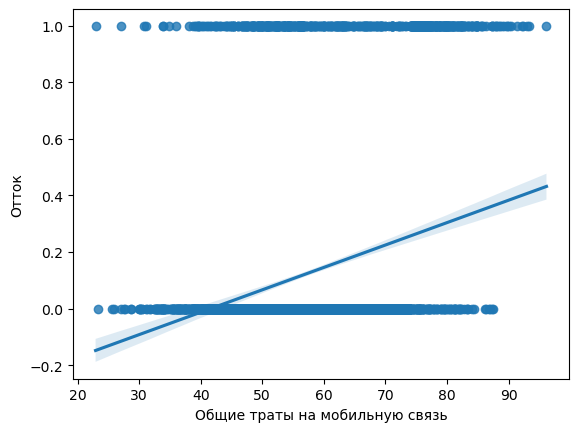

In [4]:
fig = plt.figure()
sns.regplot(data = data, x = 'total_charge', y = 'target')
plt.xlabel('Общие траты на мобильную связь')
plt.ylabel('Отток')
plt.show()

In [5]:
X = data['total_charge'].values.reshape(-1, 1)
y = data['target']
model = train_model(X, y, LinearRegression)
print('коэффициент w1', np.round(model.coef_[0], 4))
print('коэффициент w0 (intercept)', np.round(model.intercept_, 4))

коэффициент w1 0.0079
коэффициент w0 (intercept) -0.3302


$P(Y_i = 1) = -0.3302 + 0.0079 \cdot charge_i$

Рост оплаты на 1 доллар связан с ростом вероятности оттока на 0,79 процентов

# 3. Логистическая регрессия

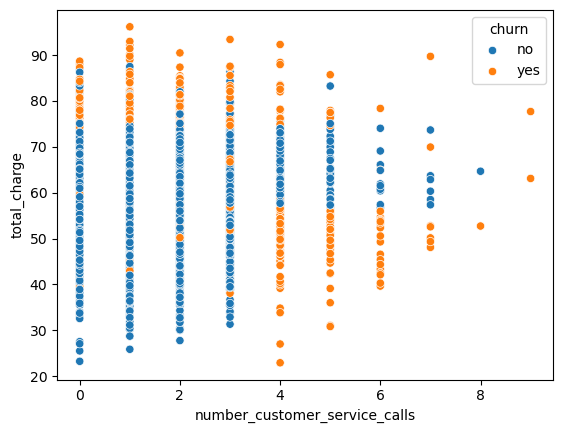

In [6]:
fig = plt.figure()
sns.scatterplot(data = data, x = 'number_customer_service_calls', y = 'total_charge', hue = 'churn')
plt.show()

In [7]:
target_col = ["target"]
features_col = ["number_customer_service_calls","total_charge"]
X_train, X_test, y_train, y_test = split_train_test(data, features_col, target_col, stratify = y)
model = train_model(X_train, y_train, LogisticRegression, kwargs = {"random_state" : 42})

C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# 4. Интерпретация результатов

In [8]:
model

LogisticRegression(random_state=42)

In [9]:
model.coef_

array([[0.41044658, 0.07253784]])

In [10]:
model.intercept_

array([-7.05417648])

$Z_i = -7.05 + 0.41 \cdot X_{1i} + 0.07 \cdot X_{2i}$

$X_1$ - number_customer_service_calls

$X_2$ - total_charge

$X_{2i} = \frac{Z_i + 7.05 - 0.41 \cdot X_{1i}}{0.07} $ - уравнение разделяющей прямой (только, чтобы нарисовать график)

$P(Y_i = 1|X) = \frac{1}{1+e^{-(-7.05 + 0.41 \cdot X_{1i} + 0.07 \cdot X_{2i})}}$ - оцененная модель логистической регрессии

In [16]:
-(w0 + w1*3 + w2*60)

array([1.4705666])

In [11]:
# Допустим, клиент А 3 раза звонил в поддержку и тратит 60 долларов на связь
# Допустим, клиент Б 4 раза звонил в поддержку и тратит 60 долларов на связь
w0 = model.intercept_
w1 = model.coef_[0, 0]
w2 = model.coef_[0, 1]
prob_a = 1 / (1 + np.exp(-(w0 + w1*3 + w2*60)))
prob_b = 1 / (1 + np.exp(-(w0 + w1*4 + w2*60)))
print("Вероятность оттока для клиента А: ", prob_a)
print("Вероятность оттока для клиента Б: ", prob_b)
# Если клиент тратит 60 долларов на связь, то увеличение звонков в поддержку с 3 до 4 повышает вероятность оттока с 18.7% до 25.7% (т.е. на 7%)

Вероятность оттока для клиента А:  [0.18685651]
Вероятность оттока для клиента Б:  [0.25728652]


In [12]:
# Допустим, клиент В 3 раза звонил в поддержку и тратит 40 долларов на связь
# Допустим, клиент Г 4 раза звонил в поддержку и тратит 40 долларов на связь
prob_c = 1 / (1 + np.exp(-(w0 + w1*3 + w2*40)))
prob_d = 1 / (1 + np.exp(-(w0 + w1*4 + w2*40)))
print("Вероятность оттока для клиента В: ", prob_c)
print("Вероятность оттока для клиента Г: ", prob_d)
# Если клиент тратит 40 долларов на связь, то увеличение звонков в поддержку с 3 до 4 повышает вероятность оттока с 5% до 7.5% (т.е. на 2.5%)

Вероятность оттока для клиента В:  [0.05110949]
Вероятность оттока для клиента Г:  [0.07509919]


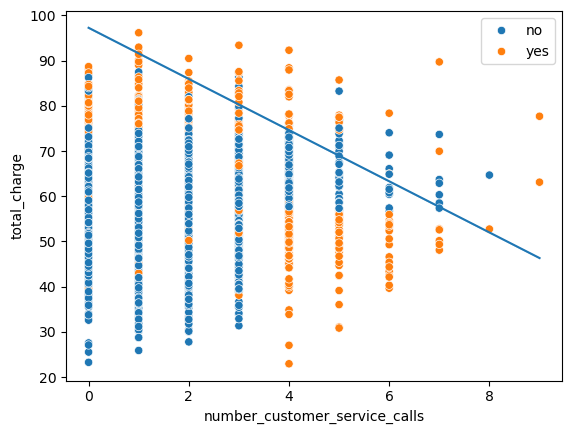

In [13]:
x2_lin = -(model.intercept_ + model.coef_[0,0]*data['number_customer_service_calls'])/model.coef_[0,1]

fig = plt.figure()
sns.scatterplot(data = data, x = 'number_customer_service_calls', y = 'total_charge', hue = 'churn')
sns.lineplot(x = data['number_customer_service_calls'], y = x2_lin)
plt.show()

In [14]:
model.predict_proba(np.array([[3, 60], [4, 60]]))[:, 1]

C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0.18685651, 0.25728652])

In [15]:
model.decision_function(np.array([[3, 60], [4, 60]]))

C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([-1.4705666 , -1.06012002])

In [17]:
1 - 1 / (1 + np.exp(model.decision_function(np.array([[3, 60], [4, 60]]))))

C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0.18685651, 0.25728652])

# 5. Предскажем вероятности оттока для тестовой выборки

In [18]:
prob_pred = model.predict_proba(X_test)[:, 1]

In [20]:
prob_pred

array([0.29255439, 0.08404149, 0.1992653 , ..., 0.08480829, 0.05356723,
       0.09408573], shape=(1650,))

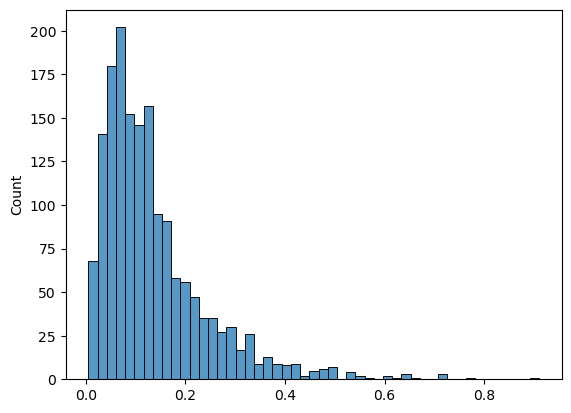

In [21]:
fig = plt.figure()
sns.histplot(prob_pred)
plt.show()

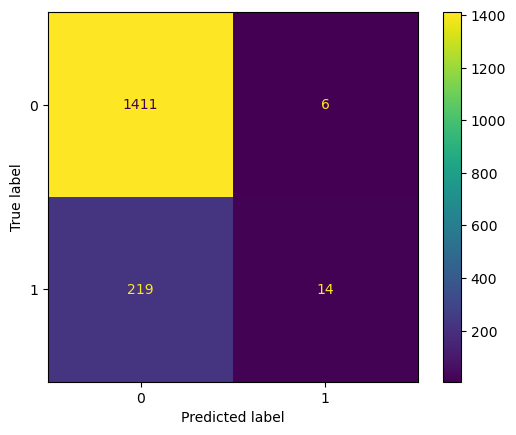

Среднее значение Y:  0.1412121212121212
Accuracy:  0.8636363636363636
Precision:  0.7
Recall:  0.060085836909871244
F1:  0.11067193675889328
ROC-AUC:  0.5279257695487959


In [24]:
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

# 6. Метрики качества

In [25]:
metrics_df = pd.DataFrame()

for threshold in np.linspace(start = 0.1, stop = 0.9, num = 17):
  y_pred = np.where(prob_pred>= threshold, 1, 0)
  df = pd.DataFrame(
      {
          'Accuracy'  : accuracy_score(y_test, y_pred),
          'Precision' : precision_score(y_test, y_pred),
          'Recall'    : recall_score(y_test, y_pred),
          'F1-score'  : f1_score(y_test, y_pred)
      },
      index = [threshold]
  )

  metrics_df = pd.concat([metrics_df, df])

metrics_df.T

,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90
Accuracy,0.559394,0.743030,0.806061,0.833939,0.850909,0.854545,0.861212,0.861212,0.863636,0.862424,0.861212,0.861212,0.860606,0.860000,0.859394,0.859394,0.859394
Precision,0.219318,0.320151,0.367781,0.404651,0.450382,0.455696,0.537037,0.558824,0.700000,0.714286,0.666667,0.833333,0.800000,1.000000,1.000000,1.000000,1.000000
Recall,0.828326,0.729614,0.519313,0.373391,0.253219,0.154506,0.124464,0.081545,0.060086,0.042918,0.034335,0.021459,0.017167,0.008584,0.004292,0.004292,0.004292
F1-score,0.346810,0.445026,0.430605,0.388393,0.324176,0.230769,0.202091,0.142322,0.110672,0.080972,0.065306,0.041841,0.033613,0.017021,0.008547,0.008547,0.008547


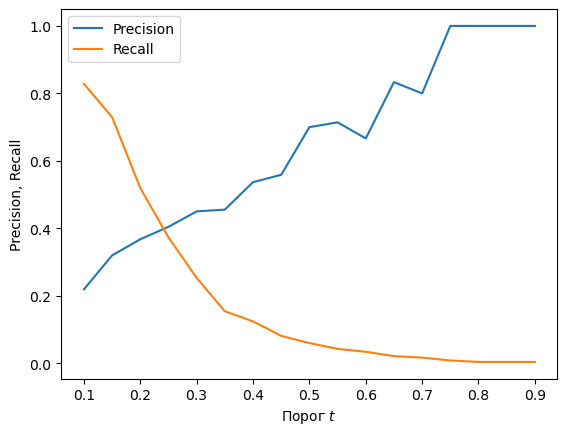

In [26]:
fig = plt.plot(figsize = (15,5))
sns.lineplot(x = metrics_df.index, y = metrics_df['Precision'], label = 'Precision')
sns.lineplot(x = metrics_df.index, y = metrics_df['Recall'], label = 'Recall')
plt.xlabel('Порог $t$')
plt.ylabel('Precision, Recall')
plt.legend()
plt.show()

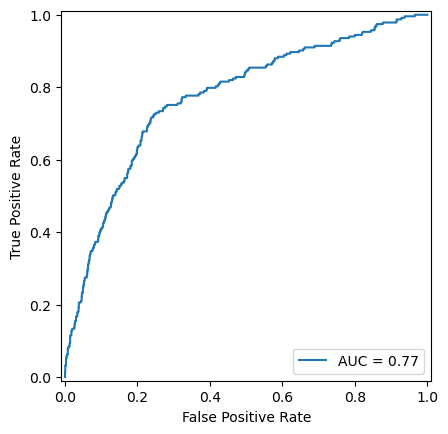

In [27]:
y_score = model.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label = model.classes_[1])
roc_auc = auc(fpr, tpr)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc = roc_auc).plot()

$TPR = \frac{TP}{TP + FN}$ - процент правильно предсказанных 1 в общем количестве 1

$FPR = \frac{FP}{TN + FP}$ - процент некорректно предсказанных 1 в общем количестве 0

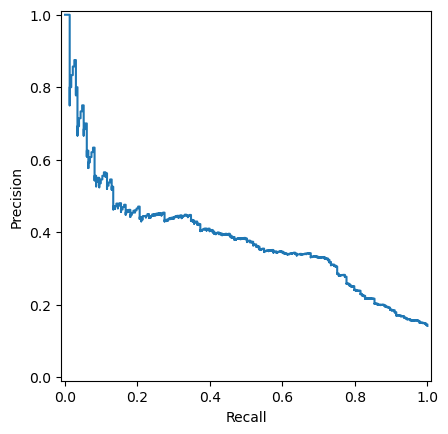

In [28]:
prec, recall, _ = precision_recall_curve(y_test, y_score, pos_label=model.classes_[1])
pr_display = PrecisionRecallDisplay(precision=prec, recall=recall).plot()

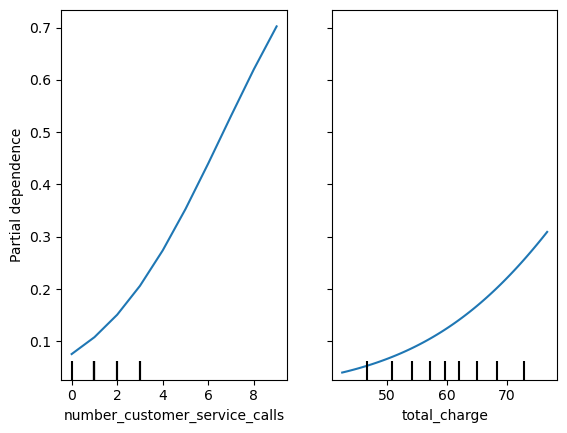

In [29]:
PartialDependenceDisplay.from_estimator(model, X_train, [0,1])

# 7. Добавим нелинейные связи признаков в модель

In [32]:
data["number_customer_service_calls2"] = data["number_customer_service_calls"]**2
data["total_charge2"] = data["total_charge"]**2
data["interaction"] = data["number_customer_service_calls"]*data["total_charge"]

In [37]:
target_col = ["target"]
features_col = ["number_customer_service_calls","number_customer_service_calls2","total_charge","total_charge2","interaction", "account_length"]
X_train, X_test, y_train, y_test = split_train_test(data, features_col, target_col, stratify = y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = train_model(X_train_scaled, y_train, LogisticRegression, kwargs = {"random_state" : 42})

C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


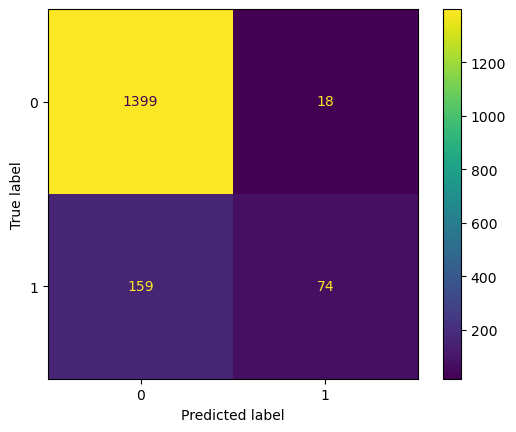

Среднее значение Y:  0.1412121212121212
Accuracy:  0.8927272727272727
Precision:  0.8043478260869565
Recall:  0.31759656652360513
F1:  0.4553846153846154
ROC-AUC:  0.6524468365433834


In [38]:
y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

# 8. Эконометрический подход

In [41]:
target_col = ["target"]
features_col = ["number_customer_service_calls","total_charge"]
X = data[features_col]
y = data[target_col]

In [42]:
X = sm.add_constant(X)
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.356473
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.1252
Time:                        11:20:49   Log-Likelihood:                -1782.4
converged:                       True   LL-Null:                       -2037.5
Covariance Type:            nonrobust   LLR p-value:                1.597e-111
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -7.2597      0.309    -23.531      0.

In [71]:
# Коэффициенты
print(result.params)

const                           -7.259726
number_customer_service_calls    0.452066
total_charge                     0.074658
dtype: float64


In [72]:
# Шансы
print(np.exp(result.params))

const                            0.000703
number_customer_service_calls    1.571555
total_charge                     1.077515
dtype: float64


In [73]:
# P-values
print(result.pvalues)

const                            1.987279e-122
number_customer_service_calls     7.817184e-50
total_charge                      2.848065e-61
dtype: float64


In [74]:
# Доверительные интервалы
print(result.conf_int())

                                      0         1
const                         -7.864421 -6.655030
number_customer_service_calls  0.392369  0.511763
total_charge                   0.065798  0.083518


In [75]:
# Предельные эффекты
print(result.get_margeff(at="overall").summary())

        Logit Marginal Effects       
Dep. Variable:                 target
Method:                          dydx
At:                           overall
                                   dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
number_customer_service_calls     0.0485      0.003     15.490      0.000       0.042       0.055
total_charge                      0.0080      0.000     17.204      0.000       0.007       0.009
